In [141]:
quit

import numpy as np
import pandas as pd
import csv
import matplotlib as mpl
import matplotlib.pyplot as plt
import pyhepmc
import itertools
import math


# Line styles
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['lines.antialiased'] = True
mpl.rcParams['lines.dashed_pattern'] = 2.8, 1.5
mpl.rcParams['lines.dashdot_pattern'] = 4.8, 1.5, 0.8, 1.5
mpl.rcParams['lines.dotted_pattern'] = 1.1, 1.1
mpl.rcParams['lines.scale_dashes'] = True

# Default colors
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler('color',['cornflowerblue','forestgreen','maroon','goldenrod','firebrick','mediumorchid', 'navy', 'brown'])

# Fonts
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'CMU Serif'
mpl.rcParams['font.sans-serif'] = 'CMU Sans Serif, DejaVu Sans, Bitstream Vera Sans, Lucida Grande, Verdana, Geneva, Lucid, Arial, Helvetica, Avant Garde, sans-serif'
mpl.rcParams['text.usetex'] = True

# Axes
mpl.rcParams['axes.linewidth'] = 1.0
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.labelpad'] = 9.0
                                                  
                                                  
# Tick marks - the essence of life
mpl.rcParams['xtick.top'] = True
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 2.5
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['xtick.minor.width'] = 0.75
mpl.rcParams['xtick.major.pad'] = 8
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 2.5
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['ytick.minor.width'] = 0.75
mpl.rcParams['ytick.major.pad'] = 8
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['ytick.minor.visible'] = True

# Legend
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['legend.frameon'] = True
mpl.rcParams['legend.framealpha'] = 1.
#mpl.rcParams['legend.edgecolor'] = 'black'
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['legend.borderpad'] = 0.4 # border whitespace
mpl.rcParams['legend.labelspacing'] = 0.5 # the vertical space between the legend entries
mpl.rcParams['legend.handlelength'] = 1.5 # the length of the legend lines
mpl.rcParams['legend.handleheight'] = 0.7 # the height of the legend handle
mpl.rcParams['legend.handletextpad'] = 0.5 # the space between the legend line and legend text
mpl.rcParams['legend.borderaxespad'] = 0.5 # the border between the axes and legend edge
mpl.rcParams['legend.columnspacing'] = 2.0 # column separation


# Figure size
mpl.rcParams['figure.figsize'] = 12, 6
mpl.rcParams['figure.dpi'] = 200

# Save details
mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['savefig.pad_inches'] = 0.1

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman']

def fix_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    
    return ax

In [177]:
def classify_isospin(isop1,isop2):
    if(isop1 == 2212 and isop2 == 2212):
        return 'pp'
    elif(isop1 == 2112 and isop2 == 2112):
        return 'nn'
    else:
        return 'np'

def get_double_diff_xsec_wgt(file, angle, delta, mybins_omega):

    emin = 2*np.sqrt(225**2 + 938**2)

    mn = 938.5

    mybins2 = np.linspace(-1.,1.,len(mybins_omega))
    mybins_leadingmom = np.linspace(225.,1500.,len(mybins_omega))
    mybins_totalE = np.linspace(emin,3000,len(mybins_omega))
    momentum_bins = np.linspace(225,1200,30)
    emiss_bins = np.linspace(0,300,30)
    init_momentum_bins = np.linspace(0,600,16)
    init_momentum_bins_more = np.linspace(0,600,30)
    
    omega_nn = np.zeros(len(mybins_omega)-1)
    omega_np = np.zeros(len(mybins_omega)-1)
    omega_pp = np.zeros(len(mybins_omega)-1)
    omega_nuc = np.zeros(len(mybins_omega)-1)

    leading_nmom_nn = np.zeros(len(mybins_leadingmom)-1)
    leading_nmom_np = np.zeros(len(mybins_leadingmom)-1)

    leading_init_mom_nn = np.zeros(len(init_momentum_bins_more)-1)
    leading_init_mom_np = np.zeros(len(init_momentum_bins_more)-1)
    subleading_init_mom_nn = np.zeros(len(init_momentum_bins_more)-1)
    subleading_init_mom_np = np.zeros(len(init_momentum_bins_more)-1)
    
    cos12_nn = np.zeros(len(mybins2)-1)
    cos12_np = np.zeros(len(mybins2)-1) 

    E_total_nn = np.zeros(len(mybins_totalE) -1)
    E_total_np = np.zeros(len(mybins_totalE) -1)

    np_momentum = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))
    nn_momentum = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))

    np_init_momentum = np.zeros((len(init_momentum_bins)-1,len(init_momentum_bins)-1))
    nn_init_momentum = np.zeros((len(init_momentum_bins)-1,len(init_momentum_bins)-1))

    Emiss_np = np.zeros((len(emiss_bins)-1))
    Emiss_nn = np.zeros((len(emiss_bins)-1))
    
    xsec = 0
    sum_of_weights = 0

    num_nn = 0
    num_np = 0
    num_pp = 0
    other = 0
    total = 0

    high_cos = math.cos((angle + delta)*np.pi/180)
    low_cos = math.cos((angle - delta)*np.pi/180)
    delta_cos = (low_cos - high_cos)
    with open(file, 'r') as f:
        xsec = float(f.readline().strip())
        while True:
            block = list(itertools.islice(f,7))
            if not block:
                break
            probe = [float(x) for x in block[0].split()]
            lep = [float(x) for x in block[1].split()]
            nuc1 = [float(x) for x in block[2].split()]
            nucp1 = [float(x) for x in block[3].split()]
            nuc2 = [float(x) for x in block[4].split()]
            nucp2 = [float(x) for x in block[5].split()]
            wgt = float(block[6])

            isospin = classify_isospin(nuc1[4],nuc2[4])

            total+=1
            sum_of_weights += wgt
            
            omega = probe[0] - lep[0]   
            probe_3 = [probe[1], probe[2], probe[3]]
            probe_mom = np.sqrt(np.dot(probe_3,probe_3))
            lep_3 = [lep[1], lep[2], lep[3]]

            nuc1_3 = [nuc1[1],nuc1[2],nuc1[3]]
            nuc2_3 = [nuc2[1],nuc2[2],nuc2[3]]
            nucp1_3 = [nucp1[1],nucp1[2],nucp1[3]]
            nucp2_3 = [nucp2[1],nucp2[2],nucp2[3]]

            qvec = np.array(probe_3) - np.array(lep_3)
            qvecmag = np.sqrt(np.dot(qvec,qvec))

            nuc1_mom = np.sqrt(np.dot(nuc1_3,nuc1_3))
            nuc2_mom = np.sqrt(np.dot(nuc2_3,nuc2_3))
            nucp1_mom = np.sqrt(np.dot(nucp1_3,nucp1_3))
            nucp2_mom = np.sqrt(np.dot(nucp2_3,nucp2_3))

            leading_mom = 0.
            totalE = nucp1[0] + nucp2[0]
            if(nucp1_mom > nucp2_mom):
                leading_mom = nucp1_mom
            else:
                leading_mom = nucp2_mom

            pp12cos = np.dot(nucp1_3,nucp2_3)/(nucp1_mom*nucp2_mom)
            
            idx0 = np.searchsorted(mybins_omega, omega, side='left')
            if idx0 > len(mybins_omega)-1:
                continue

            omega_nuc[idx0-1] += wgt 

            if(isospin == 'nn'):
                idx1 = np.searchsorted(mybins_omega,omega,side='left')
                omega_nn[idx1-1] += wgt
            if(isospin == 'np'):
                idx1 = np.searchsorted(mybins_omega,omega,side='left')
                omega_np[idx1-1] += wgt

            
        omega_bin_width = 2*np.pi*np.diff(mybins_omega)
        omega_nuc *= xsec/omega_bin_width/sum_of_weights
        omega_nn *= xsec/omega_bin_width/sum_of_weights
        omega_np *= xsec/omega_bin_width/sum_of_weights
    
    print('xsec = ',xsec)
    return omega_nuc,omega_nn,omega_np

xsec =  15688117.0


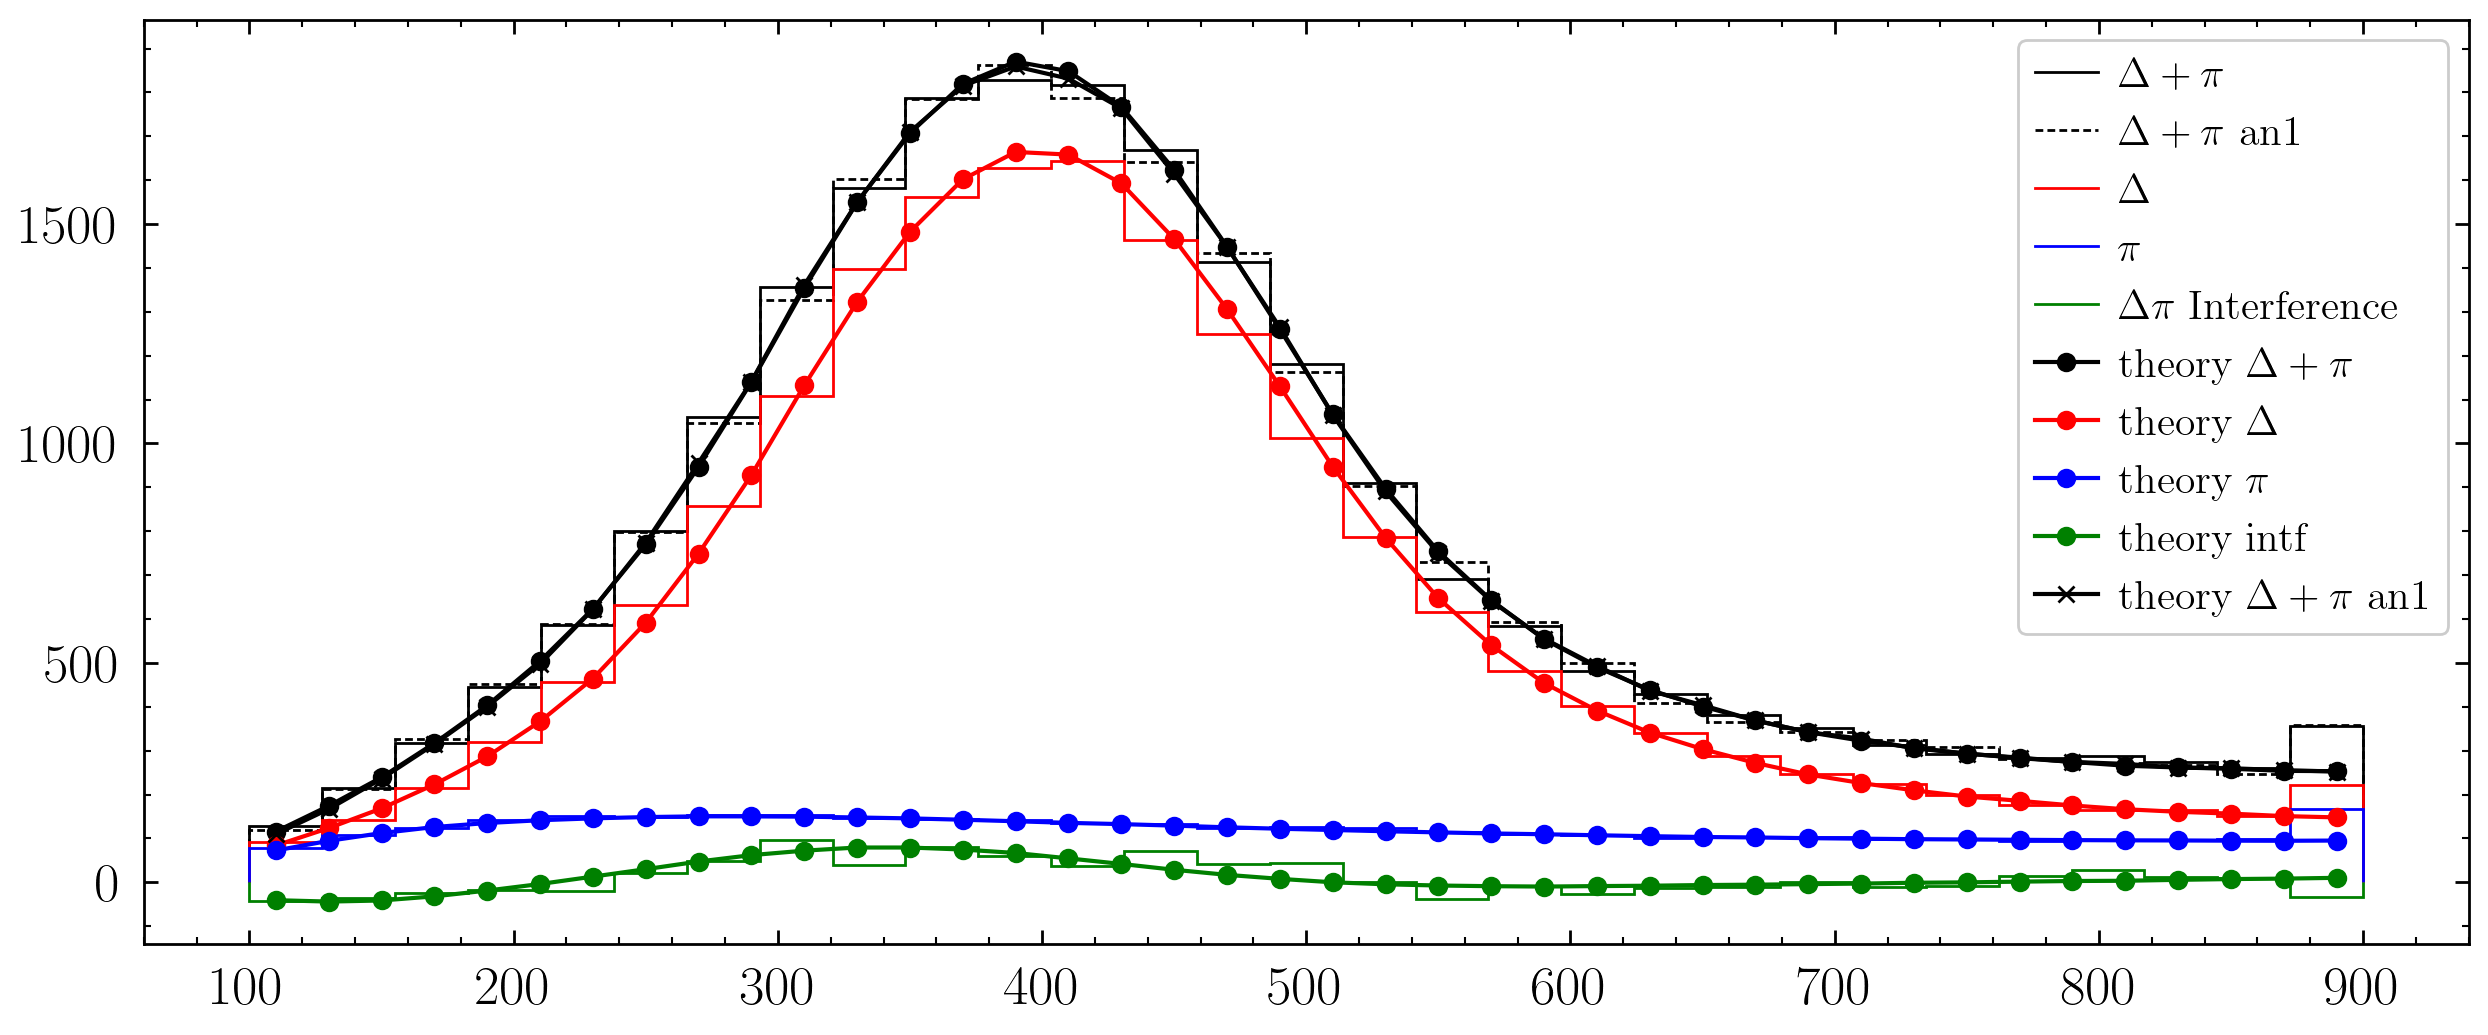

In [178]:
numbins = 30
omegalow = 100
omegahigh = 900

dtheta = 1
angle = 37.0
wbins=np.linspace(omegalow,omegahigh,numbins)


theory_totan1 = np.loadtxt('/Users/noah/Physics/Fermilab/MEC/MEC_em/code_n2b/test_FG_961_37p00_2_an1_jtot.out')
theory_xsec_totan1 = theory_totan1[:,1]

theory_tot = np.loadtxt('/Users/noah/Physics/Fermilab/MEC/MEC_em/code_n2b/test_FG_961_37p00_2_an2_jtot.out')

theory_w = theory_tot[:, 0]
theory_xsec_tot = theory_tot[:,1]

theory_delta = np.loadtxt('/Users/noah/Physics/Fermilab/MEC/MEC_em/code_n2b/test_FG_961_37p00_2_an2_jdelta.out')

theory_xsec_delta = theory_delta[:,1]

theory_pi = np.loadtxt('/Users/noah/Physics/Fermilab/MEC/MEC_em/code_n2b/test_FG_961_37p00_2_an2_jpi.out')

theory_xsec_pi = theory_pi[:,1]


theory_intf = np.loadtxt('/Users/noah/Physics/Fermilab/MEC/MEC_em/code_n2b/test_FG_961_37p00_2_an2_jdeltapi.out')

theory_xsec_intf = theory_intf[:,1]

   
#omega_nuc_delta,omega_nn,omega_np = get_double_diff_xsec_wgt('test_FG_961_37p00_2_an2_jdelta.out', angle, dtheta, wbins)
#omega_nuc_pi,omega_nn,omega_np = get_double_diff_xsec_wgt('test_FG_961_37p00_2_an2_jpi.out', angle, dtheta, wbins)
#omega_nuc_tot,omega_nn,omega_np = get_double_diff_xsec_wgt('test_FG_961_37p00_2_an2_jtot.out', angle, dtheta, wbins)


omega_nuc_tot_an1,omega_nn,omega_np = get_double_diff_xsec_wgt('test_FG_961_37p00_2_an1_jtot.out', angle, dtheta, wbins)


fig,ax = plt.subplots(1,1,figsize=(15,6))

ax.stairs(omega_nuc_tot/4,wbins,color='black',label=r'$\Delta + \pi$')
ax.stairs(omega_nuc_tot_an1/4,wbins,color='black',label=r'$\Delta + \pi$ an1',linestyle='--')
ax.stairs(omega_nuc_delta/4,wbins,color='red',label=r'$\Delta$')
ax.stairs(omega_nuc_pi/4,wbins,color='blue',label=r'$\pi$')
ax.stairs((omega_nuc_tot - omega_nuc_delta - omega_nuc_pi)/4,wbins,color='green',label=r'$\Delta\pi$ Interference')
ax.plot(theory_w, theory_xsec_tot*2, marker='o', label=r'theory $\Delta + \pi$',color='black')
ax.plot(theory_w, theory_xsec_delta*2, marker='o', label=r'theory $\Delta$',color='red')
ax.plot(theory_w, theory_xsec_pi*2, marker='o', label=r'theory $\pi$',color='blue')
ax.plot(theory_w, theory_xsec_intf*2, marker='o', label=r'theory intf',color='green')
ax.plot(theory_w, theory_xsec_totan1*2, label=r'theory $\Delta + \pi$ an1 ',color='black',marker='x')

ax.legend(fontsize=15)




In [18]:
def get_cos_from_q(Ein, w, q):
    Q2 = q**2 - w**2 
    return np.arccos(1. - Q2/(2*Ein*(Ein-w))) * 180./np.pi
    

In [40]:
get_cos_from_q(478,263,303)

27.145454862770904

In [ ]:

            if ((nuc1[4] == nuc2[4]) and nuc1[4] + nuc2[4] == pp_pid):
                # Fill histogram
                idx1 = np.searchsorted(mybins_omega, omega, side='left')
                if idx1 > len(mybins_omega)-1:
                    continue
                omega_pp[idx1-1] += wgt
                

            if ((nuc1[4] == nuc2[4]) and nuc1[4] + nuc2[4] == nn_pid):
                leading_neutron_mom = 0
                subleading_neutron_mom = 0
                
                if(nucp1_mom > nucp2_mom):
                    leading_neutron_mom = nucp1_mom
                    subleading_neutron_mom = nucp2_mom
                else:
                    leading_neutron_mom = nucp2_mom
                    subleading_neutron_mom = nucp1_mom

                
                leading_init_neutron_mom = 0
                subleading_init_neutron_mom = 0
                
                if(nuc1_mom > nuc2_mom):
                    leading_init_neutron_mom = nuc1_mom
                    subleading_init_neutron_mom = nuc2_mom
                else:
                    leading_init_neutron_mom = nuc2_mom
                    subleading_init_neutron_mom = nuc1_mom

                #Compute angle with respect to z/q
                anglepp1 = np.arccos(nucp1_3[2]/nucp1_mom)*180./np.pi
                anglepp2 = np.arccos(nucp2_3[2]/nucp2_mom)*180./np.pi

               
                T = np.sqrt(nucp1_mom**2 + mn**2) - mn
                Emiss = omega - T
                    
                # Fill histogram
                idx1 = np.searchsorted(mybins_omega, omega, side='left')
                if idx1 > len(mybins_omega)-1:
                    continue
    
                idx2 = np.searchsorted(mybins_leadingmom, leading_mom, side='left')
                if idx2 > len(mybins_leadingmom)-1:
                    continue
                    
                idx3 = np.searchsorted(mybins2, pp12cos, side='left')
                if idx3 > len(mybins2)-1:
                    continue
                    
                idx4 = np.searchsorted(mybins_totalE, totalE, side='left')
                if idx4 > len(mybins_totalE)-1:
                    continue
    
                idx5 = np.searchsorted(momentum_bins, leading_neutron_mom, side='left')
                if idx5 > len(momentum_bins) -1:
                    continue
                idx6 = np.searchsorted(momentum_bins, subleading_neutron_mom, side='left')
                if idx6 > len(momentum_bins) -1:
                    continue
    
                idx7 = np.searchsorted(init_momentum_bins, leading_init_neutron_mom, side='left')
                if idx7 > len(init_momentum_bins) -1:
                    continue
                idx8 = np.searchsorted(init_momentum_bins, subleading_init_neutron_mom, side='left')
                if idx8 > len(init_momentum_bins) -1:
                    continue
                idx9 = np.searchsorted(init_momentum_bins_more, leading_init_neutron_mom, side='left')
                if idx9 > len(init_momentum_bins_more) -1:
                    continue
                idx10 = np.searchsorted(init_momentum_bins_more, subleading_init_neutron_mom, side='left')
                if idx10 > len(init_momentum_bins_more) -1:
                    continue
                idx11 = np.searchsorted(emiss_bins, Emiss, side='left')
                if idx11 > len(emiss_bins) -1:
                    continue

                omega_nn[idx1-1] += wgt
                leading_nmom_nn[idx2-1] += wgt
                cos12_nn[idx3-1] += wgt
                E_total_nn[idx4-1] += wgt
                nn_momentum[idx5-1][idx6-1] += wgt
                nn_init_momentum[idx7-1][idx8-1] += wgt
                leading_init_mom_nn[idx9-1] += wgt
                subleading_init_mom_nn[idx10-1] += wgt
                Emiss_nn[idx11-1] += wgt

            if ((nuc1[4] != nuc2[4]) and nuc1[4] + nuc2[4] == np_pid):
                
                neutron_mom = 0
                proton_mom = 0
                neutron_init_mom = 0
                proton_init_mom = 0

                if(nucp1[4] == 2112):
                    neutron_mom = nucp1_mom
                    proton_mom = nucp2_mom
                else:
                    neutron_mom = nucp2_mom
                    proton_mom = nucp1_mom
                    
                if(nuc1[4] == 2112):
                    neutron_init_mom = nuc1_mom
                    proton_init_mom = nuc2_mom
                else:
                    neutron_init_mom = nuc2_mom
                    proton_init_mom = nuc1_mom

                if (neutron_init_mom > proton_init_mom):
                    leading_init_mom = neutron_init_mom
                    subleading_init_mom = proton_init_mom
                else:
                    leading_init_mom = proton_init_mom
                    subleading_init_mom = neutron_init_mom

                #Compute angle with respect to z/q
                anglepp1 = np.arccos(nucp1_3[2]/nucp1_mom)*180./np.pi
                anglepp2 = np.arccos(nucp2_3[2]/nucp2_mom)*180./np.pi

                
                T = np.sqrt(nucp1_mom**2 + mn**2) - mn
                Emiss = omega - T
                    
                
                # Fill histogram
                idx1 = np.searchsorted(mybins_omega, omega, side='left')
                if idx1 > len(mybins_omega)-1:
                    continue
    
                idx2 = np.searchsorted(mybins_leadingmom, leading_mom, side='left')
                if idx2 > len(mybins_leadingmom)-1:
                    continue
                    
                idx3 = np.searchsorted(mybins2, pp12cos, side='left')
                if idx3 > len(mybins2)-1:
                    continue
                    
                idx4 = np.searchsorted(mybins_totalE, totalE, side='left')
                if idx4 > len(mybins_totalE)-1:
                    continue
    
                idx5 = np.searchsorted(momentum_bins, neutron_mom, side='left')
                if idx5 > len(momentum_bins) -1:
                    continue
                idx6 = np.searchsorted(momentum_bins, proton_mom, side='left')
                if idx6 > len(momentum_bins) -1:
                    continue
    
                idx7 = np.searchsorted(init_momentum_bins, neutron_init_mom, side='left')
                if idx7 > len(init_momentum_bins) -1:
                    continue
                idx8 = np.searchsorted(init_momentum_bins, proton_init_mom, side='left')
                if idx8 > len(init_momentum_bins) -1:
                    continue
    
                idx9 = np.searchsorted(init_momentum_bins_more, leading_init_mom, side='left')
                if idx9 > len(init_momentum_bins_more) -1:
                    continue
                idx10 = np.searchsorted(init_momentum_bins_more, subleading_init_mom, side='left')
                if idx10 > len(init_momentum_bins_more) -1:
                    continue
                idx11 = np.searchsorted(emiss_bins, Emiss, side='left')
                if idx11 > len(emiss_bins) -1:
                    continue
                
                omega_np[idx1-1] += wgt
                leading_nmom_np[idx2-1] += wgt
                cos12_np[idx3-1] += wgt
                E_total_np[idx4-1] += wgt
                np_momentum[idx5-1][idx6-1] += wgt
                np_init_momentum[idx7-1][idx8-1] += wgt
                leading_init_mom_np[idx9-1] += wgt
                subleading_init_mom_np[idx10-1] += wgt
                Emiss_np[idx11-1] += wgt



        omega_nn *= xsec/omega_bin_width/sum_of_weights
        omega_np *= xsec/omega_bin_width/sum_of_weights
        omega_pp *= xsec/omega_bin_width/sum_of_weights

        cos12_bin_width = np.diff(mybins2)

        mom_bin_width = np.diff(mybins_leadingmom)

        totalE_bin_width = np.diff(mybins_totalE)

        leading_nmom_np *= xsec/mom_bin_width/sum_of_weights
        leading_nmom_nn *= xsec/mom_bin_width/sum_of_weights
        cos12_nn *= xsec/cos12_bin_width/sum_of_weights
        cos12_np *= xsec/cos12_bin_width/sum_of_weights
        E_total_nn *= xsec/totalE_bin_width/sum_of_weights
        E_total_np *= xsec/totalE_bin_width/sum_of_weights

        nn_momentum *= xsec/np.diff(momentum_bins)**2 /sum_of_weights
        np_momentum *= xsec/np.diff(momentum_bins)**2 /sum_of_weights
        nn_init_momentum *= xsec/np.diff(init_momentum_bins)**2 /sum_of_weights
        np_init_momentum *= xsec/np.diff(init_momentum_bins)**2 /sum_of_weights

        leading_init_mom_np *= xsec/np.diff(init_momentum_bins_more)**2 /sum_of_weights
        subleading_init_mom_np *= xsec/np.diff(init_momentum_bins_more)**2 /sum_of_weights
        leading_init_mom_nn *= xsec/np.diff(init_momentum_bins_more)**2 /sum_of_weights
        subleading_init_mom_nn  *= xsec/np.diff(init_momentum_bins_more)**2 /sum_of_weights

        Emiss_nn *= xsec/np.diff(emiss_bins)/sum_of_weights
        Emiss_np *= xsec/np.diff(emiss_bins)/sum_of_weights


14.77175253729988
17.8166545566007


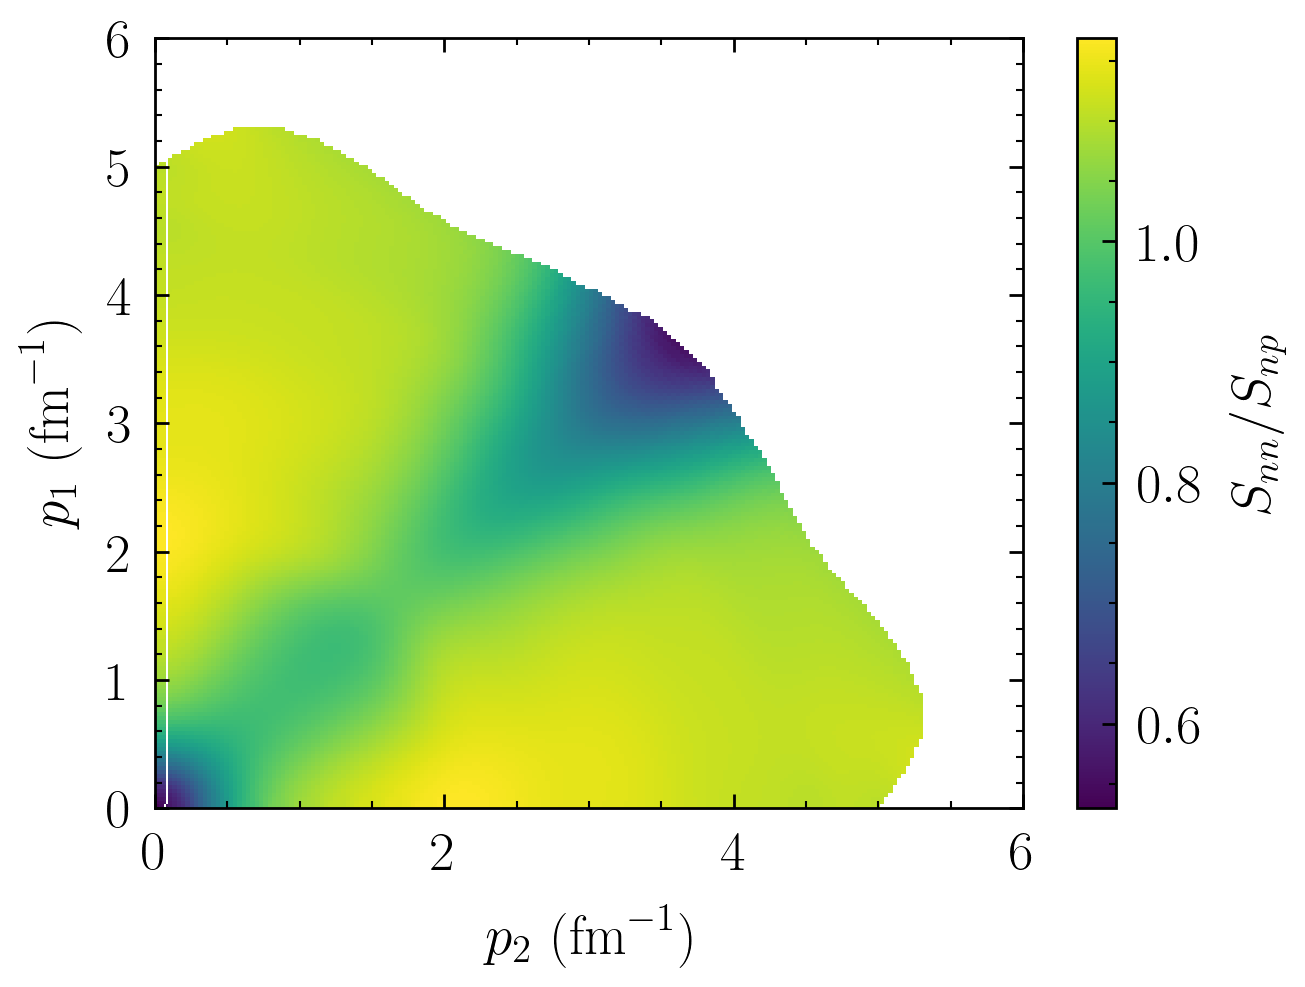

In [147]:
import pandas as pd
df = pd.read_csv('n2b_c12_new_fmt.dat',skiprows=1,header=None,sep=r"\s+")
df.columns = ["p1", "p2", "nk", "nk_1", "nk_0"]

p1_vals = np.sort(df['p1'].unique())
p2_vals = [0.015, 0.045, 0.075, 0.105, 0.135, 0.165, 0.195, 0.225,
       0.255, 0.285, 0.315, 0.345, 0.375, 0.405, 0.435, 0.465, 0.495,
       0.525, 0.555, 0.585, 0.615, 0.645, 0.675, 0.705, 0.735, 0.765,
       0.795, 0.825, 0.855, 0.885, 0.915, 0.945, 0.975, 1.005, 1.035,
       1.065, 1.095, 1.125, 1.155, 1.185, 1.215, 1.245, 1.275, 1.305,
       1.335, 1.365, 1.395, 1.425, 1.455, 1.485, 1.515, 1.545, 1.575,
       1.605, 1.635, 1.665, 1.695, 1.725, 1.755, 1.785, 1.815, 1.845,
       1.875, 1.905, 1.935, 1.965, 1.995, 2.025, 2.055, 2.085, 2.115,
       2.145, 2.175, 2.205, 2.235, 2.265, 2.295, 2.325, 2.355, 2.385,
       2.415, 2.445, 2.475, 2.505, 2.535, 2.565, 2.595, 2.625, 2.655,
       2.685, 2.715, 2.745, 2.775, 2.805, 2.835, 2.865, 2.895, 2.925,
       2.955, 2.985, 3.015, 3.045, 3.075, 3.105, 3.135, 3.165, 3.195,
       3.225, 3.255, 3.285, 3.315, 3.345, 3.375, 3.405, 3.435, 3.465,
       3.495, 3.525, 3.555, 3.585, 3.615, 3.645, 3.675, 3.705, 3.735,
       3.765, 3.795, 3.825, 3.855, 3.885, 3.915, 3.945, 3.975, 4.005,
       4.035, 4.065, 4.095, 4.125, 4.155, 4.185, 4.215, 4.245, 4.275,
       4.305, 4.335, 4.365, 4.395, 4.425, 4.455, 4.485, 4.515, 4.545,
       4.575, 4.605, 4.635, 4.665, 4.695, 4.725, 4.755, 4.785, 4.815,
       4.845, 4.875, 4.905, 4.935, 4.965, 4.995, 5.025, 5.055, 5.085,
       5.115, 5.145, 5.175, 5.205, 5.235, 5.265, 5.295, 5.325, 5.355,
       5.385, 5.415, 5.445, 5.475, 5.505, 5.535, 5.565, 5.595, 5.625,
       5.655, 5.685, 5.715, 5.745, 5.775, 5.805, 5.835, 5.865, 5.895,
       5.925, 5.955, 5.985]

dp1 = np.diff(p1_vals)[0]
dp2 = np.diff(p2_vals)[0]

nk1_integral = 0.
nk0_integral = 0.

for i,p1 in enumerate(p1_vals):
    for j,p2 in enumerate(p2_vals):

        row_index = i * 200 + j 

        nk1 = df['nk_1'][row_index]
        nk0 = df['nk_0'][row_index]

        nk1_integral += (4. * np.pi)**2 * p1**2 * p2**2 * nk1 * dp1 * dp2 / (2.*np.pi)**6
        nk0_integral += (4. * np.pi)**2 * p1**2 * p2**2 * nk0 * dp1 * dp2 / (2.*np.pi)**6

print(nk1_integral)
print(nk0_integral)


df['nk_1'] = df['nk_1'] / nk1_integral
df['nk_0'] = df['nk_0'] / nk0_integral

# 1) Compute ratio safely, avoiding division by zero
df['ratio'] = np.where(df['nk_0'] == 0, np.nan, df['nk_1'] / df['nk_0'])

# 2) Pivot so each row = p1, each column = p2, and entries = ratio
ratio_grid = df.pivot(index='p1', columns='p2', values='ratio')

# Sort indices just to be safe
ratio_grid = ratio_grid.sort_index(axis=0).sort_index(axis=1)

# 3) Extract p1, p2 values and 2D ratio array
p1_vals = ratio_grid.index.values
p2_vals = ratio_grid.columns.values
R = ratio_grid.values  # shape: (len(p1_vals), len(p2_vals))

# 4) Build meshgrid for plotting
X, Y = np.meshgrid(p2_vals, p1_vals)

# 5) Plot with pcolormesh (linear color scale by default).
plt.figure(figsize=(7, 5))
mesh = plt.pcolormesh(X, Y, R, cmap='viridis', shading='auto')

# Add colorbar
cbar = plt.colorbar(mesh)
cbar.set_label(r"$S_{nn} / S_{np}$")

plt.xlabel(r"$p_{2}$ $(\rm{fm}^{-1})$")
plt.ylabel(r"$p_{1}$ $(\rm{fm}^{-1})$")
#plt.title("Ratio (S_{np} / S_{nn}) ")
plt.show()